### Import libraries

In [50]:
import pandas as pd 
import numpy as np 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

from xgboost import XGBClassifier


### Marge the two tables

In [51]:
# Merge on Customer_ID. Both tables have one row per customer, so this is a 1:1 join.
df_1= pd.read_csv('telecom/Client.csv')
df_2= pd.read_csv('telecom/Record.csv')
df=df_1.merge(df_2, on='Customer_ID', how='inner')
df.head()

,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,...,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,...,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,...,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,...,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,...,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57


### EDA


1- Data Cleaning 

shap and types

In [52]:
df.info(verbose=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 100 entries, uniqsubs to months
dtypes: float64(69), int64(10), object(21)
memory usage: 76.3+ MB


Descriptive anlaysis 

In [53]:
df.describe()

,uniqsubs,actvsubs,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,...,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.548140,1.358960,2877.141930,7648.363833,1031.924988,960.111528,7546.314699,2836.366920,57.913832,483.726493,...,0.416283,165.280703,1.135804,10.044298,145.752225,109.666977,0.011700,1.782928,0.495620,18.833990
std,1.075255,0.655555,3790.863474,8666.558293,852.907511,840.170815,8594.889729,3756.513882,36.161292,438.485213,...,4.652627,237.332918,17.768683,15.418406,159.348094,119.594305,0.547470,5.353953,0.499983,9.655794
min,1.000000,0.000000,0.000000,0.000000,3.650000,2.400000,0.000000,0.000000,0.480000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
25%,1.000000,1.000000,889.000000,2529.000000,518.980000,452.180000,2474.000000,868.000000,35.370000,176.140000,...,0.000000,18.536667,0.000000,1.666667,38.333333,28.666667,0.000000,0.000000,0.000000,11.000000
50%,1.000000,1.000000,1822.000000,5191.500000,804.530000,737.760000,5102.500000,1789.000000,49.890000,360.190000,...,0.000000,75.841667,0.000000,5.333333,101.000000,76.000000,0.000000,0.333333,0.000000,16.000000
75%,2.000000,2.000000,3492.000000,9776.000000,1263.767500,1188.175000,9661.000000,3442.000000,69.480000,655.670000,...,0.000000,211.195000,0.000000,12.333333,199.666667,150.666667,0.000000,1.333333,1.000000,24.000000
max,196.000000,53.000000,98874.000000,233419.096700,27321.500000,27071.300000,232855.100000,98705.000000,924.270000,7040.130000,...,309.666667,4337.893333,2922.043333,489.666667,2289.000000,1894.333333,81.333333,212.666667,1.000000,61.000000


missing values

In [54]:
(df.isnull().mean() * 100).sort_values(ascending=False).head(10)

numbcars      49.366
dwllsize      38.308
HHstatin      37.923
ownrent       33.706
dwlltype      31.909
lor           30.190
income        25.436
adults        23.019
infobase      22.079
hnd_webcap    10.189
dtype: float64

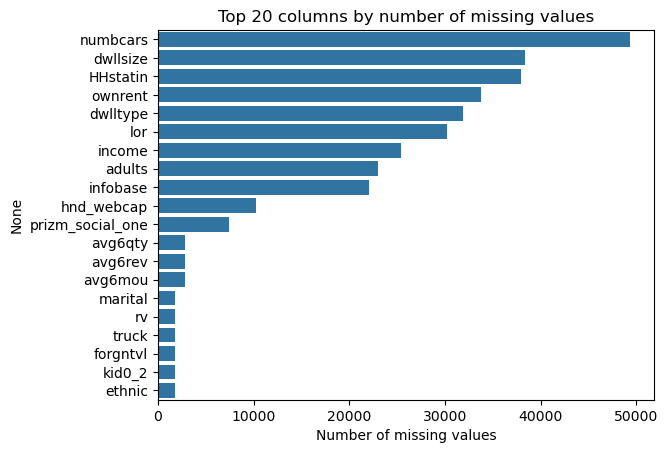

In [55]:
# Count of missing values per column
missing_counts = df.isna().sum()

# Take the 20 columns with the most missing values
top_missing = missing_counts.sort_values(ascending=False).head(20)

# Plot
sns.barplot(x=top_missing.values, y=top_missing.index)
plt.xlabel('Number of missing values')
plt.title('Top 20 columns by number of missing values')

plt.show()


Missig handling for high missing value 

In [56]:
# drop high missing / weak feature
df = df.drop(columns=['numbcars'])
# categorical with high missing  
for col in ['HHstatin', 'ownrent', 'dwlltype']:
    df[col] = df[col].fillna('Unknown')

# numeric important feature
df['lor'] = df['lor'].fillna(df['lor'].median())

Data visualization 

Heatmap for the top 10  vars that correlated with churn 

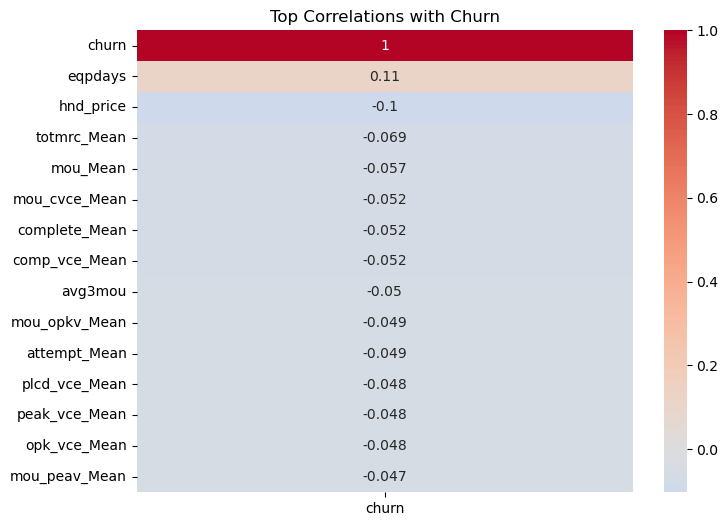

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_with_churn = (
    df.select_dtypes(include=['int64', 'float64'])
      .corr()['churn']
      .sort_values(key=abs, ascending=False)
)

top_corr = corr_with_churn.head(15)

plt.figure(figsize=(8,6))

sns.heatmap(
    top_corr.to_frame(),
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Top Correlations with Churn')
plt.show()

In [58]:
df.groupby('churn')['rev_Mean'].mean()

churn
0    59.218692
1    58.211074
Name: rev_Mean, dtype: float64

Losing one customer costs approximately 60 dollars in monthly revenue.

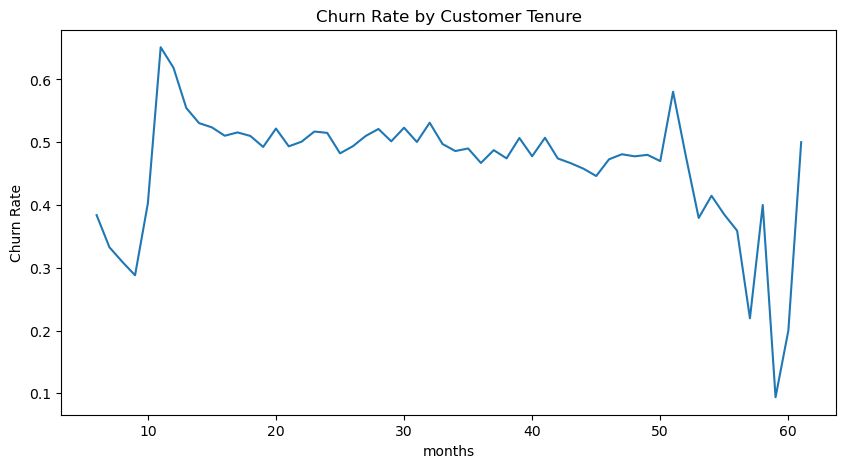

In [59]:
plt.figure(figsize=(10,5))

churn_by_month = (
    df.groupby('months')['churn']
      .mean()
      .reset_index()
)

sns.lineplot(
    data=churn_by_month,
    x='months',
    y='churn'
)

plt.title('Churn Rate by Customer Tenure')
plt.ylabel('Churn Rate')
plt.show()

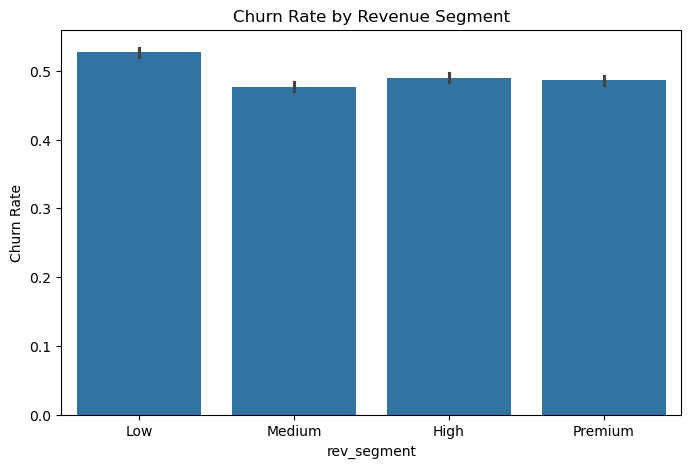

In [60]:
df['rev_segment'] = pd.qcut(
    df['rev_Mean'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Premium']
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='rev_segment',
    y='churn'
)

plt.title('Churn Rate by Revenue Segment')
plt.ylabel('Churn Rate')
plt.show()

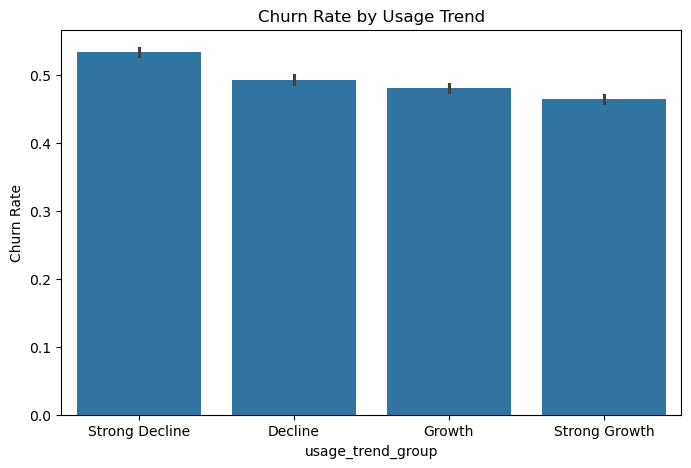

In [61]:
df['usage_trend_group'] = pd.qcut(
    df['change_mou'],
    q=4,
    labels=['Strong Decline','Decline','Growth','Strong Growth']
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='usage_trend_group',
    y='churn'
)

plt.title('Churn Rate by Usage Trend')
plt.ylabel('Churn Rate')
plt.show()

In [62]:
df.groupby('churn')['change_mou'].mean()

churn
0    -5.344265
1   -22.759003
Name: change_mou, dtype: float64

In [63]:
df.groupby('churn')['change_rev'].mean()

churn
0   -1.410195
1   -0.621263
Name: change_rev, dtype: float64

In [64]:
df.groupby('churn')['custcare_Mean'].mean()

churn
0    1.982599
1    1.595688
Name: custcare_Mean, dtype: float64

In [65]:
df.groupby('churn')['months'].mean()

churn
0    18.633074
1    19.038457
Name: months, dtype: float64

In [66]:
df.groupby('churn')['rev_Mean'].mean()

churn
0    59.218692
1    58.211074
Name: rev_Mean, dtype: float64

In [67]:
df.groupby(
    pd.qcut(df['change_mou'],5)
)['churn'].mean()

/tmp/ipykernel_265029/2526861738.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


change_mou
(-3875.001, -119.5]    0.540353
(-119.5, -28.75]       0.494153
(-28.75, 8.75]         0.508854
(8.75, 94.25]          0.456129
(94.25, 31219.25]      0.466552
Name: churn, dtype: float64

preprocessing 

In [68]:
# Drop the ID column
df_clean = df.drop(columns=['Customer_ID'])

# Find all columns that are stored as text (object dtype)
object_cols = df_clean.select_dtypes(include='object').columns.tolist()
print('Columns to encode:', object_cols)

# Encode each text column as integers
for col in object_cols:
    encoder = LabelEncoder()
    df_clean[col] = encoder.fit_transform(df_clean[col].astype(str))

print()
print('Shape after preprocessing:', df_clean.shape)
df_clean.head()

Columns to encode: ['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd']

Shape after preprocessing: (100000, 100)


,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,rev_segment,usage_trend_group
0,2,1,1,0,0,1652,4228.00000,1504.62,1453.44,4085.00,...,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,Low,Strong Decline
1,1,1,0,21,0,14654,26400.00000,2851.68,2833.88,26367.00,...,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,High,Strong Growth
2,1,1,2,7,0,7903,24385.05333,2155.91,1934.47,24303.05,...,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,Low,Growth
3,1,1,2,4,0,1502,3065.00000,2000.90,1941.81,3035.00,...,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,Medium,Growth
4,1,1,2,0,0,4485,14028.00000,2181.12,2166.48,13965.00,...,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,High,Growth


Evaluationg 


--- Running Advanced Telecom Strategic Analysis ---

[Insight 1] Call Completion Rate vs. Churn:
churn
0    0.706838
1    0.679479
Name: call_completion_rate, dtype: float64

Churn Rate by Network Quality Tier:
completion_tier
Critical Issues      0.539720
Moderate Issues      0.488881
Good Quality         0.479118
Excellent Quality    0.474760
Name: churn, dtype: float64

[Insight 2] Structural Revenue Variance (change_rev) Impact:
churn
0   -1.410195
1   -0.621263
Name: change_rev, dtype: float64

Churn Probability Matrix Based on Billing Variance (Bill Shock Grid):
rev_change_bucket
Massive Drop              0.521793
Slight Drop               0.492716
Stable Bill               0.481585
Slight Increase           0.491953
Bill Shock (>20 Extra)    0.514200
Name: churn, dtype: float64


/tmp/ipykernel_265029/2188730482.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bill_shock_matrix.index, y=bill_shock_matrix.values, palette='Blues_d')


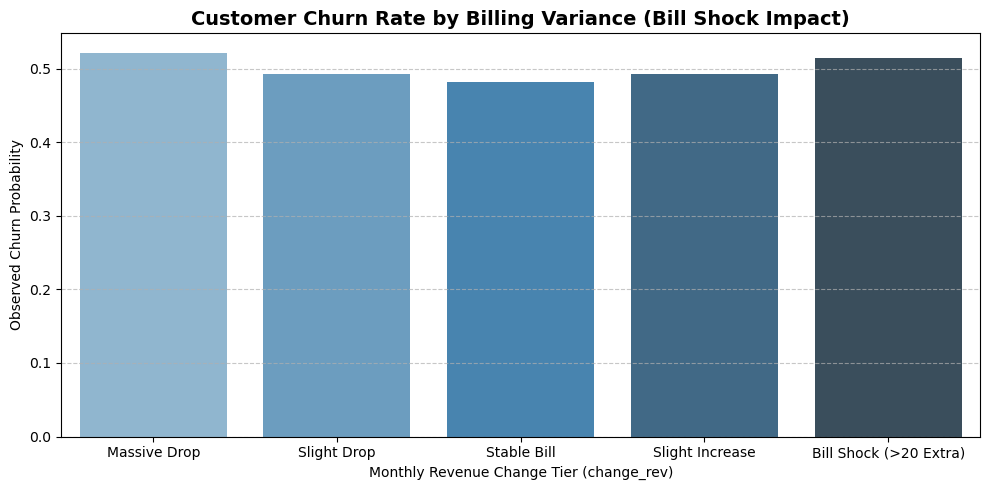

In [69]:
print("--- Running Advanced Telecom Strategic Analysis ---")

# 1. Insight A: Network Quality Friction (Dropped & Blocked Calls vs. Silent Churn)
# Creating an efficiency ratio: Completed Calls over Attempted Calls
df_clean['call_completion_rate'] = df_clean['complete_Mean'] / (df_clean['attempt_Mean'] + 0.001)

print("\n[Insight 1] Call Completion Rate vs. Churn:")
print(df_clean.groupby('churn')['call_completion_rate'].mean())

# Segmenting Call Completion into Quantiles to find the breaking point
df_clean['completion_tier'] = pd.qcut(df_clean['call_completion_rate'].fillna(0), 4, labels=['Critical Issues', 'Moderate Issues', 'Good Quality', 'Excellent Quality'])
print("\nChurn Rate by Network Quality Tier:")
print(df_clean.groupby('completion_tier', observed=False)['churn'].mean())


# 2. Insight B: Bill Shock Dynamics (Sudden Revenue Variations vs. Churn)
# Analyzing how positive or negative revenue jumps (change_rev) act as an instant trigger
print("\n[Insight 2] Structural Revenue Variance (change_rev) Impact:")
print(df_clean.groupby('churn')['change_rev'].mean())

# Let's group the revenue change to see if clients facing sudden spikes defect instantly
df_clean['rev_change_bucket'] = pd.cut(df_clean['change_rev'], 
                                       bins=[-np.inf, -20, -5, 5, 20, np.inf], 
                                       labels=['Massive Drop', 'Slight Drop', 'Stable Bill', 'Slight Increase', 'Bill Shock (>20 Extra)'])

print("\nChurn Probability Matrix Based on Billing Variance (Bill Shock Grid):")
bill_shock_matrix = df_clean.groupby('rev_change_bucket', observed=False)['churn'].mean()
print(bill_shock_matrix)

# 3. Quick Plot Generation for the Presentation
plt.figure(figsize=(10, 5))
sns.barplot(x=bill_shock_matrix.index, y=bill_shock_matrix.values, palette='Blues_d')
plt.title('Customer Churn Rate by Billing Variance (Bill Shock Impact)', fontsize=14, fontweight='bold')
plt.ylabel('Observed Churn Probability')
plt.xlabel('Monthly Revenue Change Tier (change_rev)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Data Preprocessing & Advanced Column Encoding ---
Columns fixing for XGBoost: ['rev_segment', 'usage_trend_group', 'completion_tier', 'rev_change_bucket']

Training XGBoost model...
[0]	validation_0-auc:0.64089
[50]	validation_0-auc:0.67604
[100]	validation_0-auc:0.68558
[150]	validation_0-auc:0.68937
[200]	validation_0-auc:0.69143
[249]	validation_0-auc:0.69257

================ MODEL PERFORMANCE ================
ROC-AUC Score: 0.6926
              precision    recall  f1-score   support

           0       0.64      0.62      0.63     12609
           1       0.63      0.65      0.64     12391

    accuracy                           0.64     25000
   macro avg       0.64      0.64      0.64     25000
weighted avg       0.64      0.64      0.64     25000



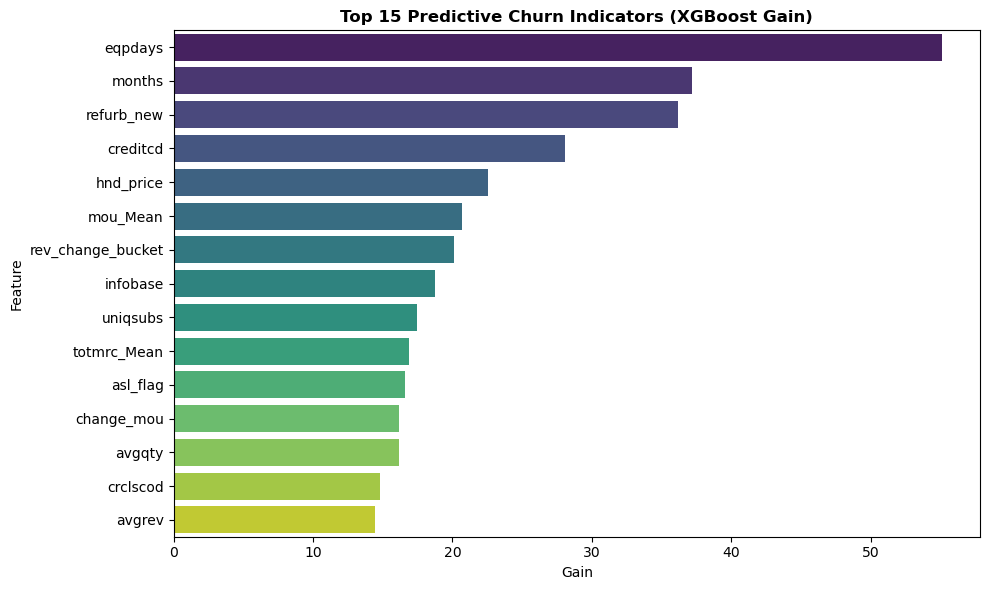

In [70]:
print("--- Data Preprocessing & Advanced Column Encoding ---")
df_ml = df_clean.copy()

categorical_and_objects = df_ml.select_dtypes(include=['object', 'category']).columns.tolist()
print('Columns fixing for XGBoost:', categorical_and_objects)

for col in categorical_and_objects:
    encoder = LabelEncoder()
    df_ml[col] = encoder.fit_transform(df_ml[col].astype(str))


X = df_ml.drop(columns=['churn'])
y = df_ml['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


balance_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
xgb_model = xgb.XGBClassifier(
    n_estimators=250,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=balance_weight,
    eval_metric='auc',
    random_state=42,
    n_jobs=8
)

print("\nTraining XGBoost model...")
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("\n================ MODEL PERFORMANCE ================")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred))

importance = xgb_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame(list(importance.items()), columns=['Feature', 'Gain']).sort_values(by='Gain', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Gain', y='Feature', data=importance_df.head(15), hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 Predictive Churn Indicators (XGBoost Gain)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

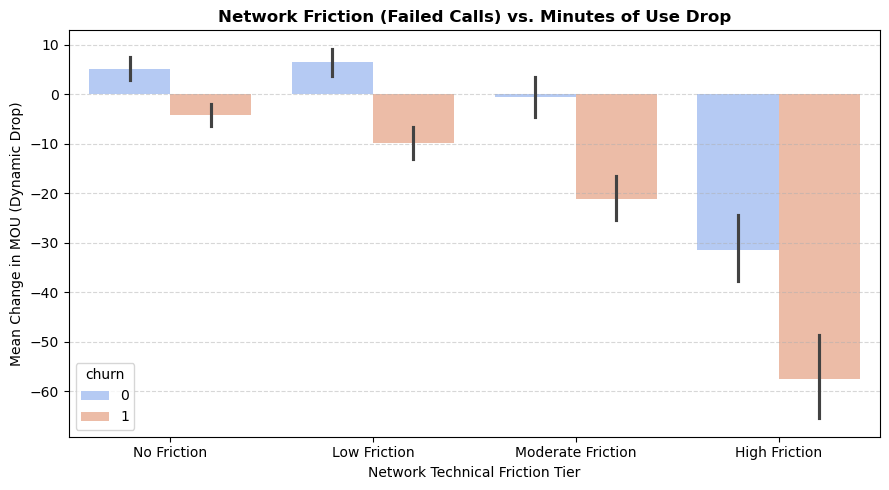

In [71]:

df_clean['total_failed_calls'] = df_clean['drop_vce_Mean'] + df_clean['blck_vce_Mean']
df_clean['failed_calls_tier'] = pd.qcut(df_clean['total_failed_calls'].fillna(0), 4, 
                                        labels=['No Friction', 'Low Friction', 'Moderate Friction', 'High Friction'])

plt.figure(figsize=(9, 5))
sns.barplot(data=df_clean, x='failed_calls_tier', y='change_mou', hue='churn', palette='coolwarm')
plt.title('Network Friction (Failed Calls) vs. Minutes of Use Drop', fontsize=12, fontweight='bold')
plt.xlabel('Network Technical Friction Tier')
plt.ylabel('Mean Change in MOU (Dynamic Drop)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


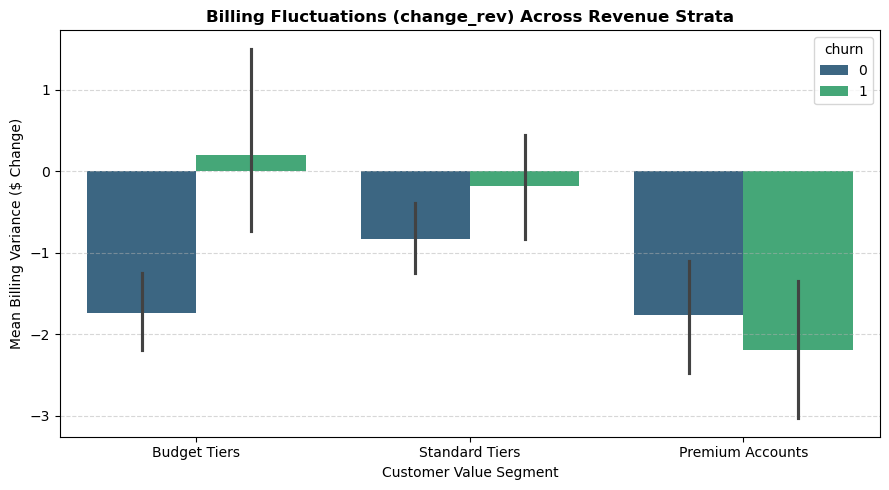

In [72]:

df_clean['revenue_bracket'] = pd.qcut(df_clean['totmrc_Mean'].fillna(0), 3, labels=['Budget Tiers', 'Standard Tiers', 'Premium Accounts'])

plt.figure(figsize=(9, 5))
sns.barplot(data=df_clean, x='revenue_bracket', y='change_rev', hue='churn', palette='viridis')
plt.title('Billing Fluctuations (change_rev) Across Revenue Strata', fontsize=12, fontweight='bold')
plt.xlabel('Customer Value Segment')
plt.ylabel('Mean Billing Variance ($ Change)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()